# Статистические основы A/B-тестирования


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, ttest_ind

# Настройка стиля графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## Одновыборочный критерий Стьюдента

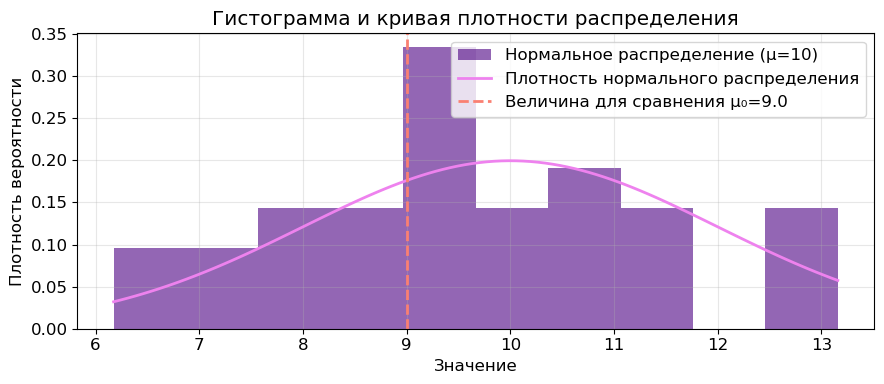

In [4]:

# 1. Генерация выборок
np.random.seed(42)  # для воспроизводимости результатов

# Параметры распределений
mean_normal = 10    # среднее нормального распределения
std_normal = 2      # стандартное отклонение
n_samples = 30      # количество примеров
mu0 = 9.0           # величина для сравнения. Попробучте использовать близкие Среднему значения и отличающиеся. 
                    # Как при этом меняются значения статистических критериев?

# Первая выборка из нормального распределения
sample_normal = np.random.normal(mean_normal, std_normal, n_samples)

# Вторая выборка - значения близкие к среднему первой выборки
# Генерируем список одинаковых значений
sample_close = [mu0 for n in range(n_samples)]

# 2. Построение гистограмм и кривых плотности
fig, (ax1) = plt.subplots(1, figsize=(9, 4))

# Левый график: гистограммы и кривые плотности
ax1.hist(sample_normal, bins=10, density=True, alpha=0.6, color='indigo', 
         label=f'Нормальное распределение (μ={mean_normal})')
         

# Кривая плотности для нормального распределения
x_range = np.linspace(sample_normal.min(), sample_normal.max(), 100)
ax1.plot(x_range, stats.norm.pdf(x_range, mean_normal, std_normal), 
        'violet', linewidth=2, label='Плотность нормального распределения')

# Пунктирная линия для среднего значения второй выборки
ax1.axvline(mu0, color='salmon', linestyle='--', linewidth=2, 
           label=f'Величина для сравнения \u03BC₀={mu0}')

ax1.set_title('Гистограмма и кривая плотности распределения')
ax1.set_xlabel('Значение')
ax1.set_ylabel('Плотность вероятности')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [5]:
# 3. Расчет Skewness и Kurtosis для первой выборки
skewness = stats.skew(sample_normal)
kurtosis = stats.kurtosis(sample_normal)

print("СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ  ВЫБОРКИ:")
print("=" * 50)
print(f"Skewness (асимметрия): {skewness:.4f}")
print(f"Kurtosis (эксцесс): {kurtosis:.4f}")
print(f"Среднее значение: {np.mean(sample_normal):.4f}")
print(f"Медиана: {np.median(sample_normal):.4f}") # Обратите внимание на отличие различие значений Среднего и Медианы в выборке 
print(f"Стандартное отклонение: {np.std(sample_normal, ddof=1):.4f}")
print(f"Минимальное значение: {np.min(sample_normal):.4f}")
print(f"Максимальное значение: {np.max(sample_normal):.4f}")
print()

СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ  ВЫБОРКИ:
Skewness (асимметрия): 0.1492
Kurtosis (эксцесс): -0.3609
Среднее значение: 9.6237
Медиана: 9.5317
Стандартное отклонение: 1.8000
Минимальное значение: 6.1734
Максимальное значение: 13.1584



In [6]:
# 4. Тест Шапиро-Уилка для первой выборки
shapiro_test = shapiro(sample_normal)
alpha = 0.05

print("ТЕСТ ШАПИРО-УИЛКА ДЛЯ  ВЫБОРКИ:")
print("=" * 50)
print(f"Статистика: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4f}")
print(f"Уровень значимости (α): {alpha}")
print(f"Нормальность распределения: {shapiro_test.pvalue > alpha}")
if shapiro_test.pvalue > alpha:
    print("✓ Распределение не отличается от нормального")
else:
    print("✗ Распределение отличается от нормального")
print()

ТЕСТ ШАПИРО-УИЛКА ДЛЯ  ВЫБОРКИ:
Статистика: 0.9751
p-value: 0.6868
Уровень значимости (α): 0.05
Нормальность распределения: True
✓ Распределение не отличается от нормального



In [7]:
# 5. t-test и график
# Проведение t-test
t_test_result = ttest_ind(sample_normal, sample_close)
print("РЕЗУЛЬТАТЫ T-TEST:")
print("=" * 50)
print(f"t-статистика: {t_test_result.statistic:.4f}")
print(f"p-value: {t_test_result.pvalue:.4f}")
print(f"Степени свободы: {len(sample_normal) + len(sample_close) - 2}")

# Расчет доверительного интервала
confidence_level = 0.95
diff_mean = np.mean(sample_normal) - np.mean(sample_close)
std_error = np.sqrt(np.var(sample_normal, ddof=1)/len(sample_normal) +            # ddof=1 !!!!!
                   np.var(sample_close, ddof=1)/len(sample_close))

ci_low, ci_high = stats.t.interval(confidence_level, 
                                  df=len(sample_normal)+len(sample_close)-2, 
                                  loc=diff_mean, 
                                  scale=std_error)

print(f"Разница средних: {diff_mean:.4f}")
print(f"{int(confidence_level*100)}% доверительный интервал разницы средних: [{ci_low:.4f}, {ci_high:.4f}]")

РЕЗУЛЬТАТЫ T-TEST:
t-статистика: 1.8979
p-value: 0.0627
Степени свободы: 58
Разница средних: 0.6237
95% доверительный интервал разницы средних: [-0.0341, 1.2815]


C:\Users\iTonyJah\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


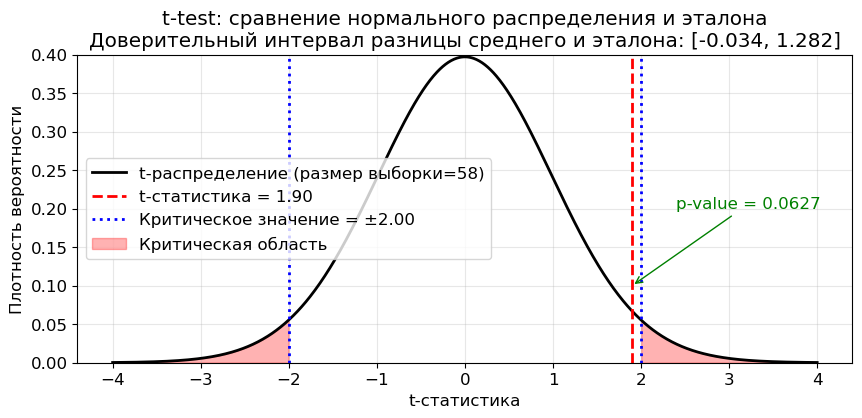

In [9]:
# Построение графика для t-test
plt.figure(figsize=(10, 4))

# Распределение t-статистики
df = len(sample_normal) + len(sample_close) - 2                                     # поправка на выборку
x_t = np.linspace(-4, 4, 1000)
t_dist = stats.t.pdf(x_t, df=df)

plt.plot(x_t, t_dist, 'black', linewidth=2, label=f't-распределение (размер выборки={df})')    # индикация поправки на выборку 
plt.axvline(t_test_result.statistic, color='red', linestyle='--', linewidth=2,
           label=f't-статистика = {t_test_result.statistic:.2f}')

# Область критических значений
critical_value = stats.t.ppf(1 - (1-confidence_level)/2, df)
plt.axvline(critical_value, color='blue', linestyle=':', linewidth=2,
           label=f'Критическое значение = ±{critical_value:.2f}')
plt.axvline(-critical_value, color='blue', linestyle=':', linewidth=2)

# Заливка критических областей
x_fill_left = np.linspace(-4, -critical_value, 100)
x_fill_right = np.linspace(critical_value, 4, 100)
plt.fill_between(x_fill_left, stats.t.pdf(x_fill_left, df), 
                alpha=0.3, color='red', label='Критическая область')
plt.fill_between(x_fill_right, stats.t.pdf(x_fill_right, df), 
                alpha=0.3, color='red')

# Аннотации
plt.annotate(f'p-value = {t_test_result.pvalue:.4f}', 
            xy=(t_test_result.statistic, 0.1), 
            xytext=(t_test_result.statistic + 0.5, 0.2),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=12, color='green')

plt.title('t-test: сравнение нормального распределения и эталона\n'
         f'Доверительный интервал разницы среднего и эталона: [{ci_low:.3f}, {ci_high:.3f}]')
plt.xlabel('t-статистика')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.4)
plt.show()


## Двухвыборочный критерий Стьюдента
## Независимые выборки, t - критерий

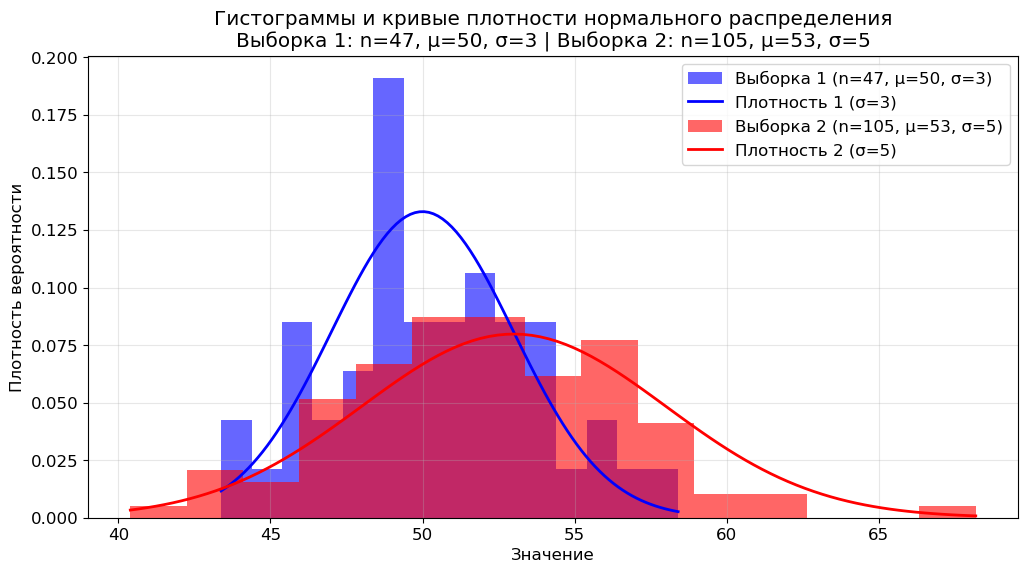

In [10]:

# Настройка стиля графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# 1. Генерация выборок
np.random.seed(4222)  # для воспроизводимости результатов

# Параметры распределений
mean1 = 50          # среднее первой выборки
mean2 = 53          # среднее второй выборки (большее)
n1 = 47             # размер первой выборки
n2 = 105            # размер второй выборки (больше)

# Дисперсии: большая выборка имеет большую дисперсию
std1 = 3            # стандартное отклонение первой выборки
std2 = 5            # стандартное отклонение второй выборки (больше)

# Генерация выборок
sample1 = np.random.normal(mean1, std1, n1)
sample2 = np.random.normal(mean2, std2, n2)

# 2. Построение гистограмм и кривых плотности
plt.figure(figsize=(12, 6))

# Гистограмма и кривая плотности для первой выборки
plt.hist(sample1, bins=15, density=True, alpha=0.6, color='blue', 
         label=f'Выборка 1 (n={n1}, μ={mean1}, σ={std1})')

# Кривая плотности для первой выборки
x1 = np.linspace(min(sample1), max(sample1), 100)
plt.plot(x1, stats.norm.pdf(x1, mean1, std1), 'blue', linewidth=2, 
         label=f'Плотность 1 (σ={std1})')

# Гистограмма и кривая плотности для второй выборки
plt.hist(sample2, bins=15, density=True, alpha=0.6, color='red', 
         label=f'Выборка 2 (n={n2}, μ={mean2}, σ={std2})')

# Кривая плотности для второй выборки
x2 = np.linspace(min(sample2), max(sample2), 100)
plt.plot(x2, stats.norm.pdf(x2, mean2, std2), 'red', linewidth=2, 
         label=f'Плотность 2 (σ={std2})')

plt.title('Гистограммы и кривые плотности нормального распределения\n'
          f'Выборка 1: n={n1}, μ={mean1}, σ={std1} | '
          f'Выборка 2: n={n2}, μ={mean2}, σ={std2}')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# 3. Расчет Skewness и Kurtosis для обеих выборок
skewness1 = stats.skew(sample1)
skewness2 = stats.skew(sample2)
kurtosis1 = stats.kurtosis(sample1)
kurtosis2 = stats.kurtosis(sample2)

print("СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ВЫБОРОК:")
print("=" * 60)
print("ВЫБОРКА 1:")
print(f"Skewness (асимметрия): {skewness1:.4f}")
print(f"Kurtosis (эксцесс): {kurtosis1:.4f}")
print(f"Среднее: {np.mean(sample1):.4f}")
print(f"Медиана: {np.median(sample1):.4f}")
print(f"Стандартное отклонение: {np.std(sample1, ddof=1):.4f}")
print(f"Дисперсия: {np.var(sample1, ddof=1):.4f}")
print()

print("ВЫБОРКА 2:")
print(f"Skewness (асимметрия): {skewness2:.4f}")
print(f"Kurtosis (эксцесс): {kurtosis2:.4f}")
print(f"Среднее: {np.mean(sample2):.4f}")
print(f"Медиана: {np.median(sample2):.4f}")
print(f"Стандартное отклонение: {np.std(sample2, ddof=1):.4f}")
print(f"Дисперсия: {np.var(sample2, ddof=1):.4f}")
print()

# 4. Тест Шапиро-Уилка для обеих выборок
shapiro_test1 = shapiro(sample1)
shapiro_test2 = shapiro(sample2)
alpha = 0.05

print("ТЕСТ ШАПИРО-УИЛКА:")
print("=" * 60)
print("ВЫБОРКА 1:")
print(f"Статистика: {shapiro_test1.statistic:.4f}")
print(f"p-value: {shapiro_test1.pvalue:.4f}")
print(f"Нормальность: {shapiro_test1.pvalue > alpha}")
print()

print("ВЫБОРКА 2:")
print(f"Статистика: {shapiro_test2.statistic:.4f}")
print(f"p-value: {shapiro_test2.pvalue:.4f}")
print(f"Нормальность: {shapiro_test2.pvalue > alpha}")
print()

# 5. t-test и график
# Проведение t-test (равные дисперсии не предполагаются)
t_test_result = ttest_ind(sample1, sample2, equal_var=False)

print("РЕЗУЛЬТАТЫ T-TEST (Welch's t-test):")
print("=" * 60)
print(f"t-статистика: {t_test_result.statistic:.4f}")
print(f"p-value: {t_test_result.pvalue:.4f}")

# Расчет доверительного интервала для разницы средних
confidence_level = 0.95
diff_mean = np.mean(sample1) - np.mean(sample2)

# Стандартная ошибка для неравных дисперсий
se = np.sqrt(np.var(sample1, ddof=1)/len(sample1) + np.var(sample2, ddof=1)/len(sample2))

# Степени свободы для Welch's t-test
df_welch = (se**4) / (
    (np.var(sample1, ddof=1)**2 / (len(sample1)**2 * (len(sample1)-1)) +
     np.var(sample2, ddof=1)**2 / (len(sample2)**2 * (len(sample2)-1)))
)

ci_low, ci_high = stats.t.interval(confidence_level, 
                                  df=df_welch, 
                                  loc=diff_mean, 
                                  scale=se)



СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ВЫБОРОК:
ВЫБОРКА 1:
Skewness (асимметрия): 0.1888
Kurtosis (эксцесс): -0.3978
Среднее: 50.2558
Медиана: 49.9686
Стандартное отклонение: 3.4390
Дисперсия: 11.8270

ВЫБОРКА 2:
Skewness (асимметрия): 0.2677
Kurtosis (эксцесс): 0.6250
Среднее: 52.1641
Медиана: 51.8560
Стандартное отклонение: 4.6100
Дисперсия: 21.2522

ТЕСТ ШАПИРО-УИЛКА:
ВЫБОРКА 1:
Статистика: 0.9886
p-value: 0.9223
Нормальность: True

ВЫБОРКА 2:
Статистика: 0.9900
p-value: 0.6294
Нормальность: True

РЕЗУЛЬТАТЫ T-TEST (Welch's t-test):
t-статистика: -2.8320
p-value: 0.0055


Разница средних: -1.9083
Стандартная ошибка: 0.6738
Степени свободы (Welch): 116.4
95% доверительный интервал: [-3.2428, -0.5737]


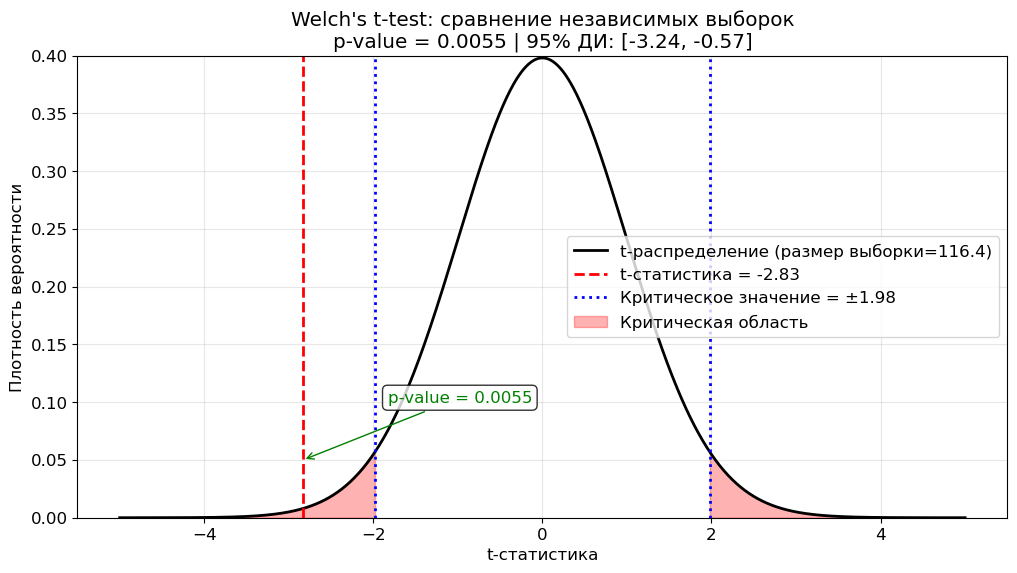

In [12]:
print(f"Разница средних: {diff_mean:.4f}")
print(f"Стандартная ошибка: {se:.4f}")
print(f"Степени свободы (Welch): {df_welch:.1f}")
print(f"{int(confidence_level*100)}% доверительный интервал: [{ci_low:.4f}, {ci_high:.4f}]")

# Построение графика для t-test
plt.figure(figsize=(12, 6))

# Распределение t-статистики
x_t = np.linspace(-5, 5, 1000)
t_dist = stats.t.pdf(x_t, df=df_welch)

plt.plot(x_t, t_dist, 'black', linewidth=2, label=f't-распределение (размер выборки={df_welch:.1f})')
plt.axvline(t_test_result.statistic, color='red', linestyle='--', linewidth=2,
           label=f't-статистика = {t_test_result.statistic:.2f}')

# Критические значения
critical_value = stats.t.ppf(1 - (1-confidence_level)/2, df_welch)
plt.axvline(critical_value, color='blue', linestyle=':', linewidth=2,
           label=f'Критическое значение = ±{critical_value:.2f}')
plt.axvline(-critical_value, color='blue', linestyle=':', linewidth=2)

# Критические области
x_fill_left = np.linspace(-5, -critical_value, 100)
x_fill_right = np.linspace(critical_value, 5, 100)
plt.fill_between(x_fill_left, stats.t.pdf(x_fill_left, df_welch), 
                alpha=0.3, color='red', label='Критическая область')
plt.fill_between(x_fill_right, stats.t.pdf(x_fill_right, df_welch), 
                alpha=0.3, color='red')

# Аннотации
plt.annotate(f'p-value = {t_test_result.pvalue:.4f}', 
            xy=(t_test_result.statistic, 0.05), 
            xytext=(t_test_result.statistic + 1, 0.1),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=12, color='green',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Welch\'s t-test: сравнение независимых выборок\n'
         f'p-value = {t_test_result.pvalue:.4f} | '
         f'95% ДИ: [{ci_low:.2f}, {ci_high:.2f}]')
plt.xlabel('t-статистика')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.4)
plt.show()


## Двухвыборочный критерий Стьюдента
## Зезависимые выборки, t - критерий

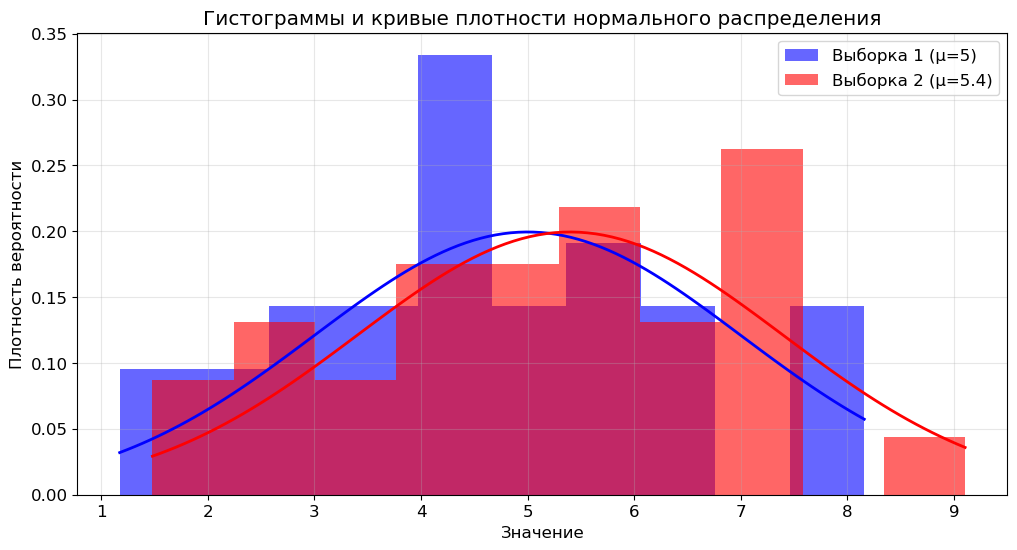

In [13]:
# 1. Генерация выборок
np.random.seed(42)  # для воспроизводимости результатов

# Параметры распределений
mean1, mean2 = 5, 5.4  # разные средние
std = 2               # одинаковая дисперсия (стандартное отклонение)
n_samples = 30        # количество примеров

# Генерация выборок
sample1 = np.random.normal(mean1, std, n_samples)
sample2 = np.random.normal(mean2, std, n_samples)

# 2. Построение гистограмм и кривых плотности
plt.figure(figsize=(12, 6))

# Гистограмма и кривая плотности для первой выборки
plt.hist(sample1, bins=10, density=True, alpha=0.6, color='blue', label=f'Выборка 1 (μ={mean1})')
x1 = np.linspace(min(sample1), max(sample1), 100)
plt.plot(x1, stats.norm.pdf(x1, mean1, std), 'blue', linewidth=2)

# Гистограмма и кривая плотности для второй выборки
plt.hist(sample2, bins=10, density=True, alpha=0.6, color='red', label=f'Выборка 2 (μ={mean2})')
x2 = np.linspace(min(sample2), max(sample2), 100)
plt.plot(x2, stats.norm.pdf(x2, mean2, std), 'red', linewidth=2)

plt.title('Гистограммы и кривые плотности нормального распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# 3. Расчет Skewness и Kurtosis
skewness1 = stats.skew(sample1)
skewness2 = stats.skew(sample2)
kurtosis1 = stats.kurtosis(sample1)
kurtosis2 = stats.kurtosis(sample2)

print("Выборка 1:")
print(f"Skewness (асимметрия): {skewness1:.4f}")
print(f"Kurtosis (эксцесс): {kurtosis1:.4f}\n")

print("Выборка 2:")
print(f"Skewness (асимметрия): {skewness2:.4f}")
print(f"Kurtosis (эксцесс): {kurtosis2:.4f}\n")

# 4. Тест Шапиро-Уилка
shapiro_test1 = shapiro(sample1)
shapiro_test2 = shapiro(sample2)

print("Тест Шапиро-Уилка:")
print(f"Выборка 1: статистика = {shapiro_test1.statistic:.4f}, p-value = {shapiro_test1.pvalue:.4f}")
print(f"Выборка 2: статистика = {shapiro_test2.statistic:.4f}, p-value = {shapiro_test2.pvalue:.4f}")

# Интерпретация результатов теста Шапиро-Уилка
alpha = 0.05
print(f"\nИнтерпретация (α = {alpha}):")
print(f"Выборка 1 нормальна: {shapiro_test1.pvalue > alpha}")
print(f"Выборка 2 нормальна: {shapiro_test2.pvalue > alpha}")

# 5. t-test и график
# Проведение t-test
t_test_result = ttest_ind(sample1, sample2)
print(f"\nРезультаты t-test:")
print(f"t-статистика: {t_test_result.statistic:.4f}")
print(f"p-value: {t_test_result.pvalue:.4f}")



Выборка 1:
Skewness (асимметрия): 0.1492
Kurtosis (эксцесс): -0.3609

Выборка 2:
Skewness (асимметрия): -0.1046
Kurtosis (эксцесс): -0.6118

Тест Шапиро-Уилка:
Выборка 1: статистика = 0.9751, p-value = 0.6868
Выборка 2: статистика = 0.9837, p-value = 0.9130

Интерпретация (α = 0.05):
Выборка 1 нормальна: True
Выборка 2 нормальна: True

Результаты t-test:
t-статистика: -1.1292
p-value: 0.2634


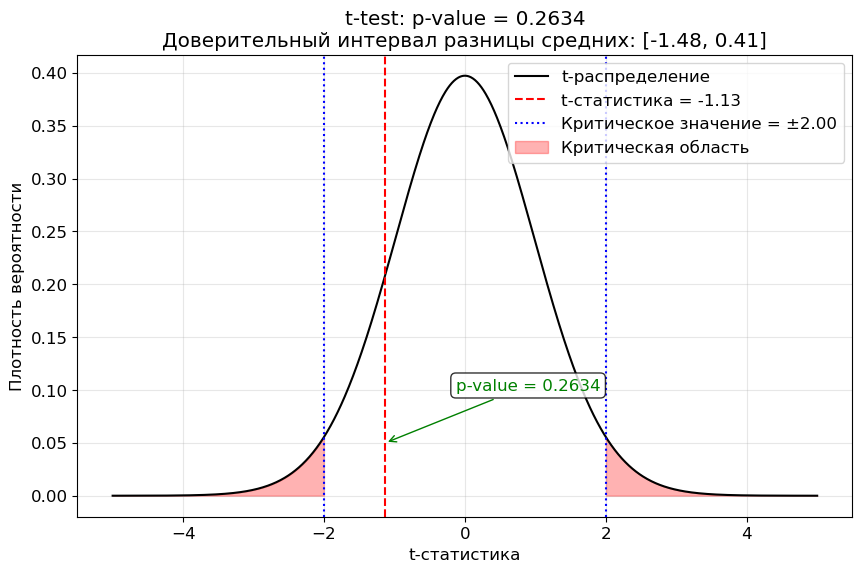


Дополнительная информация:
Разница средних: -0.5340
95% доверительный интервал разницы средних: [-1.4805, 0.4126]
Среднее выборки 1: 4.6237
Среднее выборки 2: 5.1577
Стандартное отклонение выборки 1: 1.8000
Стандартное отклонение выборки 2: 1.8622


In [15]:
# Расчет доверительного интервала
confidence_level = 0.95
diff_mean = np.mean(sample1) - np.mean(sample2)
std_error = np.sqrt(np.var(sample1, ddof=1)/len(sample1) + np.var(sample2, ddof=1)/len(sample2))
ci_low, ci_high = stats.t.interval(confidence_level, 
                                  df=len(sample1)+len(sample2)-2, 
                                  loc=diff_mean, 
                                  scale=std_error)

# Построение графика для t-test
plt.figure(figsize=(10, 6))

# Распределение t-статистики
x_t = np.linspace(-5, 5, 1000)
t_dist = stats.t.pdf(x_t, df=len(sample1)+len(sample2)-2)

plt.plot(x_t, t_dist, 'black', label='t-распределение')
plt.axvline(t_test_result.statistic, color='red', linestyle='--', 
           label=f't-статистика = {t_test_result.statistic:.2f}')

# Область критических значений
critical_value = stats.t.ppf(1 - (1-confidence_level)/2, len(sample1)+len(sample2)-2)
plt.axvline(critical_value, color='blue', linestyle=':', label=f'Критическое значение = ±{critical_value:.2f}')
plt.axvline(-critical_value, color='blue', linestyle=':')

# Заливка критических областей
x_fill = np.linspace(-5, -critical_value, 100)
plt.fill_between(x_fill, stats.t.pdf(x_fill, len(sample1)+len(sample2)-2), 
                alpha=0.3, color='red', label='Критическая область')
x_fill = np.linspace(critical_value, 5, 100)
plt.fill_between(x_fill, stats.t.pdf(x_fill, len(sample1)+len(sample2)-2), 
                alpha=0.3, color='red')
# Аннотации
plt.annotate(f'p-value = {t_test_result.pvalue:.4f}', 
            xy=(t_test_result.statistic, 0.05), 
            xytext=(t_test_result.statistic + 1, 0.1),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=12, color='green',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.title(f't-test: p-value = {t_test_result.pvalue:.4f}\n'
         f'Доверительный интервал разницы средних: [{ci_low:.2f}, {ci_high:.2f}]')
plt.xlabel('t-статистика')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительная информация
print(f"\nДополнительная информация:")
print(f"Разница средних: {diff_mean:.4f}")
print(f"95% доверительный интервал разницы средних: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Среднее выборки 1: {np.mean(sample1):.4f}")
print(f"Среднее выборки 2: {np.mean(sample2):.4f}")
print(f"Стандартное отклонение выборки 1: {np.std(sample1, ddof=1):.4f}")
print(f"Стандартное отклонение выборки 2: {np.std(sample2, ddof=1):.4f}")